# Soil porosity by USDA texture class and bulk density (Rosetta)

This notebook uses the **Rosetta** pedotransfer functions ([usda-ars-ussl/rosetta-soil](https://github.com/usda-ars-ussl/rosetta-soil)) to estimate, for **every USDA soil texture class** (using representative *median* sand/silt/clay values) and for **bulk densities from 0.8 to 2.0 g/cm³ in 0.1 steps**:

| Output | Definition |
|---|---|
| **Total porosity** | Saturated volumetric water content θₛ (van Genuchten) |
| **Field-capacity porosity** | Volumetric water content at 33 kPa (= 330 cm suction) |
| **Permanent-wilting-point porosity** | Volumetric water content at 1500 kPa (= 15000 cm suction) |

Rosetta predicts the **van Genuchten** water-retention parameters (θᵣ, θₛ, α, n) from texture + bulk density. We then evaluate the retention curve at the field-capacity and wilting-point suctions.

**van Genuchten (1980) retention model:**
$$\theta(h) = \theta_r + \frac{\theta_s - \theta_r}{\left[1 + (\alpha\,h)^{n}\right]^{m}}, \qquad m = 1 - \tfrac{1}{n}$$

where $h$ is the suction head [cm] and $\alpha$ [1/cm], $n$ [-], $\theta_r$, $\theta_s$ are Rosetta outputs.

**Environment:** built with [pixi](https://pixi.sh) (`pixi.toml`). Run `pixi install`, then open this notebook with the `soil_modeling` kernel (`pixi run jupyter lab`).

In [1]:
import numpy as np
import pandas as pd
from rosetta import rosetta, SoilData

pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

## 1. Representative (median) texture values for each USDA class

Sand / silt / clay percentages below are the widely used central (representative) values for each of the 12 USDA texture classes. Each triplet sums to 100% and plots inside the correct region of the USDA texture triangle. Adjust these if you prefer a different convention (e.g. the geometric or modified centroids of Levi, 2017, SSSAJ).

In [2]:
# texture_class: (sand %, silt %, clay %)
TEXTURE_CLASSES = {
    "sand":            (92,  5,  3),
    "loamy sand":      (82, 12,  6),
    "sandy loam":      (65, 25, 10),
    "loam":            (40, 40, 20),
    "silt loam":       (20, 65, 15),
    "silt":            ( 7, 88,  5),
    "sandy clay loam": (60, 13, 27),
    "clay loam":       (30, 35, 35),
    "silty clay loam": (10, 56, 34),
    "sandy clay":      (50,  7, 43),
    "silty clay":      ( 7, 47, 46),
    "clay":            (20, 20, 60),
}

texture_df = (
    pd.DataFrame.from_dict(
        TEXTURE_CLASSES, orient="index", columns=["sand_pct", "silt_pct", "clay_pct"]
    )
    .rename_axis("texture_class")
    .reset_index()
)

# sanity check: each class sums to 100%
assert (texture_df[["sand_pct", "silt_pct", "clay_pct"]].sum(axis=1) == 100).all()
texture_df

,texture_class,sand_pct,silt_pct,clay_pct
0,sand,92,5,3
1,loamy sand,82,12,6
2,sandy loam,65,25,10
3,loam,40,40,20
4,silt loam,20,65,15
5,silt,7,88,5
6,sandy clay loam,60,13,27
7,clay loam,30,35,35
8,silty clay loam,10,56,34
9,sandy clay,50,7,43


## 2. Bulk-density range and suction set-points

In [3]:
# Bulk density 0.8 -> 2.0 g/cm3 in 0.1 steps (rounded to avoid float drift)
bulk_densities = np.round(np.arange(0.8, 2.0 + 1e-9, 0.1), 1)

# Suction heads (cm) at which to evaluate the retention curve
H_FIELD_CAPACITY = 330.0    # 33 kPa
H_WILTING_POINT = 15000.0   # 1500 kPa

print(f"{len(bulk_densities)} bulk densities: {bulk_densities}")

13 bulk densities: [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]


## 3. van Genuchten retention helper

In [4]:
def vg_theta(h, theta_r, theta_s, alpha, n):
    """Volumetric water content at suction head h [cm] (van Genuchten, 1980).

    Parameters may be scalars or numpy arrays (broadcast together).
    alpha [1/cm], n [-], theta_r/theta_s [cm3/cm3]. m = 1 - 1/n.
    """
    theta_r = np.asarray(theta_r, dtype=float)
    theta_s = np.asarray(theta_s, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    n = np.asarray(n, dtype=float)
    m = 1.0 - 1.0 / n
    return theta_r + (theta_s - theta_r) / (1.0 + (alpha * h) ** n) ** m

## 4. Run Rosetta and build the results DataFrame

Rosetta input columns are `[sand%, silt%, clay%, bulk_density]`; model version **3** (2017 recalibration) is used. The mean output columns are `[θᵣ, θₛ, α, n, Ksat, K0, L]` with α in 1/cm and n dimensionless (linear, not log₁₀).

In [5]:
# Build every (texture class) x (bulk density) combination
rows = [
    {
        "texture_class": cls,
        "sand_pct": sand,
        "silt_pct": silt,
        "clay_pct": clay,
        "bulk_density_g_cm3": bd,
    }
    for cls, (sand, silt, clay) in TEXTURE_CLASSES.items()
    for bd in bulk_densities
]
df = pd.DataFrame(rows)

# Rosetta expects [sand, silt, clay, bulk_density]
rosetta_input = df[["sand_pct", "silt_pct", "clay_pct", "bulk_density_g_cm3"]].to_numpy()
mean, stdev, codes = rosetta(3, SoilData.from_iter(rosetta_input.tolist()))
mean = np.asarray(mean)

theta_r, theta_s, alpha, n = mean[:, 0], mean[:, 1], mean[:, 2], mean[:, 3]

df["total_porosity"] = theta_s
df["field_capacity_porosity"] = vg_theta(H_FIELD_CAPACITY, theta_r, theta_s, alpha, n)
df["wilting_point_porosity"] = vg_theta(H_WILTING_POINT, theta_r, theta_s, alpha, n)
df["available_water_capacity"] = (
    df["field_capacity_porosity"] - df["wilting_point_porosity"]
)
df["rosetta_code"] = np.asarray(codes)  # 3 = texture + bulk density model

print(f"{len(df)} rows  ({len(TEXTURE_CLASSES)} classes x {len(bulk_densities)} bulk densities)")
df.head(15)

156 rows  (12 classes x 13 bulk densities)


,texture_class,sand_pct,silt_pct,clay_pct,bulk_density_g_cm3,total_porosity,field_capacity_porosity,wilting_point_porosity,available_water_capacity,rosetta_code
0,sand,92,5,3,0.800,0.560,0.141,0.072,0.069,3
1,sand,92,5,3,0.900,0.531,0.129,0.068,0.062,3
2,sand,92,5,3,1.000,0.503,0.113,0.064,0.049,3
3,sand,92,5,3,1.100,0.475,0.096,0.061,0.036,3
4,sand,92,5,3,1.200,0.450,0.082,0.058,0.024,3
5,sand,92,5,3,1.300,0.425,0.072,0.056,0.016,3
6,sand,92,5,3,1.400,0.401,0.064,0.054,0.010,3
7,sand,92,5,3,1.500,0.376,0.059,0.052,0.007,3
8,sand,92,5,3,1.600,0.352,0.057,0.050,0.006,3
9,sand,92,5,3,1.700,0.327,0.056,0.049,0.007,3


## 5. Results

In [6]:
result = df[[
    "texture_class",
    "sand_pct",
    "silt_pct",
    "clay_pct",
    "bulk_density_g_cm3",
    "total_porosity",
    "field_capacity_porosity",
    "wilting_point_porosity",
    "available_water_capacity",
]].copy()

result

,texture_class,sand_pct,silt_pct,clay_pct,bulk_density_g_cm3,total_porosity,field_capacity_porosity,wilting_point_porosity,available_water_capacity
0,sand,92,5,3,0.800,0.560,0.141,0.072,0.069
1,sand,92,5,3,0.900,0.531,0.129,0.068,0.062
2,sand,92,5,3,1.000,0.503,0.113,0.064,0.049
3,sand,92,5,3,1.100,0.475,0.096,0.061,0.036
4,sand,92,5,3,1.200,0.450,0.082,0.058,0.024
...,...,...,...,...,...,...,...,...,...
151,clay,20,20,60,1.600,0.425,0.345,0.230,0.115
152,clay,20,20,60,1.700,0.395,0.330,0.230,0.099
153,clay,20,20,60,1.800,0.366,0.313,0.230,0.083
154,clay,20,20,60,1.900,0.338,0.295,0.228,0.067


In [7]:
# Save to CSV
result.to_csv("rosetta_porosity_by_texture.csv", index=False)
print("Wrote rosetta_porosity_by_texture.csv")

Wrote rosetta_porosity_by_texture.csv


## 6. Quick visualization (optional)

Total porosity, field-capacity porosity, and wilting-point porosity vs. bulk density for each texture class.

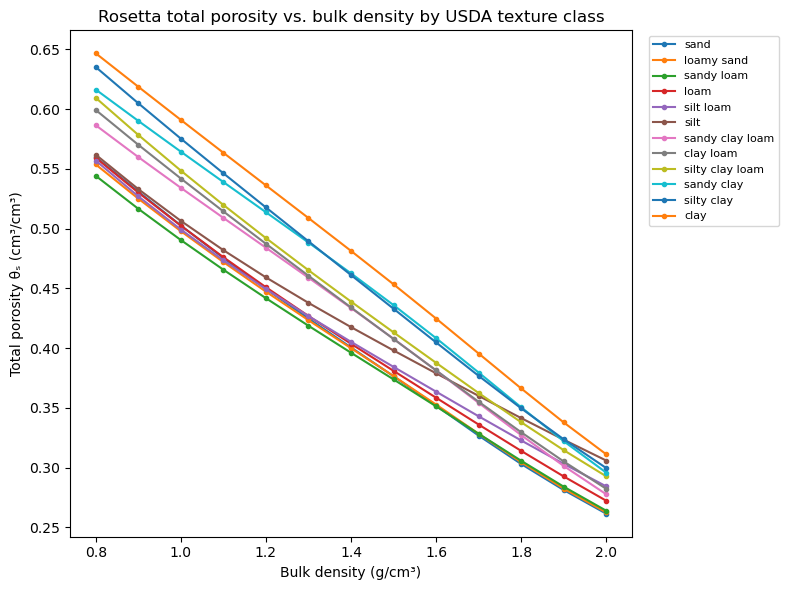

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
for cls, sub in result.groupby("texture_class", sort=False):
    ax.plot(sub["bulk_density_g_cm3"], sub["total_porosity"], marker="o", ms=3, label=cls)
ax.set_xlabel("Bulk density (g/cm³)")
ax.set_ylabel("Total porosity θₛ (cm³/cm³)")
ax.set_title("Rosetta total porosity vs. bulk density by USDA texture class")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

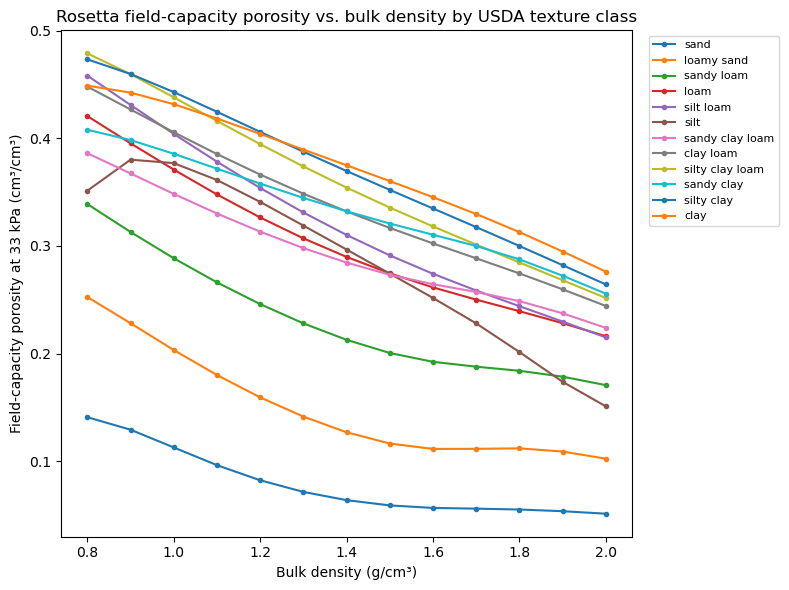

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for cls, sub in result.groupby("texture_class", sort=False):
    ax.plot(sub["bulk_density_g_cm3"], sub["field_capacity_porosity"], marker="o", ms=3, label=cls)
ax.set_xlabel("Bulk density (g/cm³)")
ax.set_ylabel("Field-capacity porosity at 33 kPa (cm³/cm³)")
ax.set_title("Rosetta field-capacity porosity vs. bulk density by USDA texture class")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

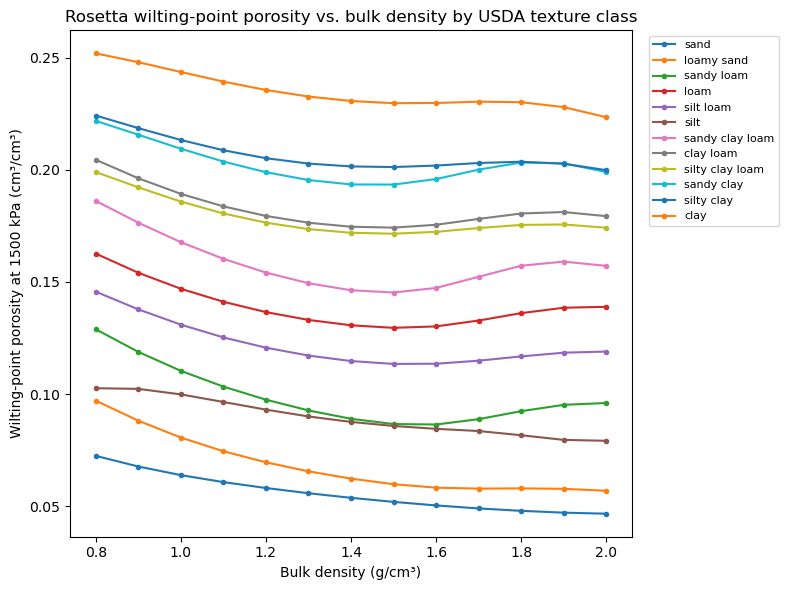

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for cls, sub in result.groupby("texture_class", sort=False):
    ax.plot(sub["bulk_density_g_cm3"], sub["wilting_point_porosity"], marker="o", ms=3, label=cls)
ax.set_xlabel("Bulk density (g/cm³)")
ax.set_ylabel("Wilting-point porosity at 1500 kPa (cm³/cm³)")
ax.set_title("Rosetta wilting-point porosity vs. bulk density by USDA texture class")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()